*  Applied siamese NN from the Keras examples to the Kaggle MNIST dataset.

*  Added simple prediction based on the distance from the 10 random samples of every class.

*  Added NN embeddings visualisation.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))
# Any results you write to the current directory are saved as output.

import matplotlib.pyplot as plt
get_ipython().magic(u'matplotlib inline')
plt.style.use('ggplot')


['train.csv', 'sample_submission.csv', 'test.csv']


In [2]:
'''Trains a Siamese MLP on pairs of digits from the MNIST dataset.
It follows Hadsell-et-al.'06 [1] by computing the Euclidean distance on the
output of the shared network and by optimizing the contrastive loss (see paper
for mode details).
# References
- Dimensionality Reduction by Learning an Invariant Mapping
    http://yann.lecun.com/exdb/publis/pdf/hadsell-chopra-lecun-06.pdf
Gets to 97.2% test accuracy after 20 epochs.
2 seconds per epoch on a Titan X Maxwell GPU
'''
from __future__ import absolute_import
from __future__ import print_function

import random
from keras.models import Model
from keras.layers import Input, Flatten, Dense, Dropout, Lambda
from keras.optimizers import RMSprop
from keras import backend as K

num_classes = 10
epochs = 10


def euclidean_distance(vects):
    x, y = vects
    sum_square = K.sum(K.square(x - y), axis=1, keepdims=True)
    return K.sqrt(K.maximum(sum_square, K.epsilon()))


def eucl_dist_output_shape(shapes):
    shape1, shape2 = shapes
    return (shape1[0], 1)


def contrastive_loss(y_true, y_pred):
    '''Contrastive loss from Hadsell-et-al.'06
    http://yann.lecun.com/exdb/publis/pdf/hadsell-chopra-lecun-06.pdf
    '''
    margin = 1
    sqaure_pred = K.square(y_pred)
    margin_square = K.square(K.maximum(margin - y_pred, 0))
    return K.mean(y_true * sqaure_pred + (1 - y_true) * margin_square)


def create_pairs(x, digit_indices):
    '''Positive and negative pair creation.
    Alternates between positive and negative pairs.
    labels = [1, 0, 1, 0, 1, 0, ...]
    '''
    pairs = []
    labels = []
    n = min([len(digit_indices[d]) for d in range(num_classes)]) - 1
    for d in range(num_classes):
        for i in range(n):
            # horizental 
            z1, z2 = digit_indices[d][i], digit_indices[d][i + 1]
            pairs.append([x[z1], x[z2]])
            
            # vertical 
            inc = random.randrange(1, num_classes)
            dn = (d + inc) % num_classes
            z1, z2 = digit_indices[d][i], digit_indices[dn][i]
            pairs.append([x[z1], x[z2]])
            
            labels += [1, 0]
    return np.array(pairs), np.array(labels)


def create_base_network(input_shape):
    '''Base network to be shared (eq. to feature extraction).
    '''
    input = Input(shape=input_shape)
    x = Flatten()(input)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.1)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.1)(x)
    x = Dense(128, activation='relu')(x)
    x = Lambda(lambda  x: K.l2_normalize(x,axis=1))(x)
    x = Lambda(lambda  x: K.l2_normalize(x,axis=1))(x)
    return Model(input, x)


def compute_accuracy(y_true, y_pred):
    '''Compute classification accuracy with a fixed threshold on distances.
    '''
    pred = y_pred.ravel() < 0.5
    return np.mean(pred == y_true)


def accuracy(y_true, y_pred):
    '''Compute classification accuracy with a fixed threshold on distances.
    '''
    return K.mean(K.equal(y_true, K.cast(y_pred < 0.5, y_true.dtype)))

Using TensorFlow backend.


In [3]:
# load and reshape data
train = pd.read_csv('../input/train.csv')
test = pd.read_csv('../input/test.csv')
train_labels =train['label']
train_images =train.drop(['label'],axis=1)

train_data = np.array(train_images).reshape(-1,28,28)
train_label = np.array(train_labels)
test_x = np.array(test).reshape(-1,28,28)

In [4]:
# the data, split between train and test sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(train_data, train_labels, test_size=0.2, shuffle=True, random_state=1)
print("Train data shape: {}.".format(x_train.shape))
print("Test data shape {}.".format(test_x.shape))

x_train = x_train.astype('float32')/255 # train
x_test = x_test.astype('float32')/255 # validation
test_x = test_x/255  # produce submission.csv

input_shape = x_train.shape[1:]

Train data shape: (33600, 28, 28).
Test data shape (28000, 28, 28).


In [5]:
# create training+test positive and negative pairs
digit_indices = [np.where(y_train == i)[0] for i in range(num_classes)]
tr_pairs, tr_y = create_pairs(x_train, digit_indices)
# digit_indices.shape = [10, ?] 
# tr_pairs.shape = (61260, 2, 28, 28)
# tr_y.shape = (61260, )

digit_indices = [np.where(y_test == i)[0] for i in range(num_classes)]
te_pairs, te_y = create_pairs(x_test, digit_indices)
# digit_indices.shape = [10, ?] 
# te_pairs.shape = (14600, 2, 28, 28)
# te_y.shape = (14600, )

In [6]:
# network definition
base_network = create_base_network(input_shape)

input_a = Input(shape=input_shape)
input_b = Input(shape=input_shape)

# because we re-use the same instance `base_network`,
# the weights of the network
# will be shared across the two branches
processed_a = base_network(input_a)
processed_b = base_network(input_b)

distance = Lambda(euclidean_distance,
                  output_shape=eucl_dist_output_shape)([processed_a, processed_b])

model = Model([input_a, input_b], distance)

# train
rms = RMSprop()
#rms = Adam()
#rms = SGD()

model.compile(loss=contrastive_loss, optimizer=rms, metrics=[accuracy])
# train

# tr_pairs[:, 0].shape = (61260, 28, 28)
# tr_pairs[:, 1]
# tr_y.shape = (61260, )
# te_pairs[:, 0].shape = (14600, 28, 28)


history = model.fit([tr_pairs[:, 0], tr_pairs[:, 1]], tr_y,
          batch_size=128,
          epochs=epochs,
          validation_data=([te_pairs[:, 0], te_pairs[:, 1]], te_y))

# compute final accuracy on training and test sets
y_pred_tr = model.predict([tr_pairs[:, 0], tr_pairs[:, 1]])
tr_acc = compute_accuracy(tr_y, y_pred_tr)
y_pred_te = model.predict([te_pairs[:, 0], te_pairs[:, 1]])
te_acc = compute_accuracy(te_y, y_pred_te)

print('* Accuracy on training set: %0.2f%%' % (100 * tr_acc))
print('* Accuracy on test set: %0.2f%%' % (100 * te_acc))


Train on 61260 samples, validate on 14600 samples
Epoch 1/10
61260/61260 [==============================] - 6s 93us/step - loss: 0.0889 - accuracy: 0.8939 - val_loss: 0.0460 - val_accuracy: 0.9508
Epoch 2/10
61260/61260 [==============================] - 4s 58us/step - loss: 0.0384 - accuracy: 0.9602 - val_loss: 0.0336 - val_accuracy: 0.9627
Epoch 3/10
61260/61260 [==============================] - 4s 58us/step - loss: 0.0249 - accuracy: 0.9731 - val_loss: 0.0290 - val_accuracy: 0.9651
Epoch 4/10
61260/61260 [==============================] - 4s 58us/step - loss: 0.0183 - accuracy: 0.9795 - val_loss: 0.0259 - val_accuracy: 0.9672
Epoch 5/10
61260/61260 [==============================] - 6s 96us/step - loss: 0.0145 - accuracy: 0.9832 - val_loss: 0.0249 - val_accuracy: 0.9687
Epoch 6/10
61260/61260 [==============================] - 8s 123us/step - loss: 0.0124 - accuracy: 0.9855 - val_loss: 0.0255 - val_accuracy: 0.9688
Epoch 7/10
61260/61260 [==============================] - 6s 104us/

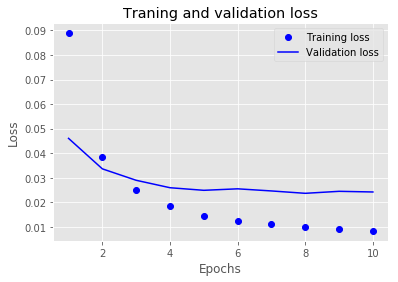

In [7]:
# Loss Learning Curves
history_dict = history.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']


epochs = range(1, (len(accuracy) + 1))
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss,'b', label='Validation loss')
plt.title('Traning and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


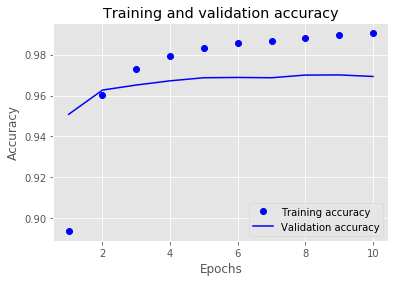

In [8]:
# Accuracy Learning Curve
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [9]:
# create test pairs
# make compare template 
digit_indices = [np.where(y_train == i)[0] for i in range(num_classes)]
example_numbers = 10
example_indexes = [np.random.choice((digit_indices[i]), example_numbers, replace=False) for i in range(num_classes)]
# (10, 10)

In [10]:
from PIL import Image

predictions = []
for sub in range(0, len(test_x)): # 28000
    print('Processing {}'.format(sub))
    image_sub = test_x[sub].reshape(1, 28, 28)
    
    pred_sum = []
    for i in range(0, num_classes):
        raw_prediction = []
        for exam in range(0, example_numbers):
            example_image = x_train[example_indexes[i][exam]].reshape(1, 28, 28) # 0-9 random image
            prd = model.predict([image_sub, example_image])
            prd = np.squeeze(prd)
            raw_prediction.append(prd)
        pred_sum.append(sum(raw_prediction))
        
    prediction = [np.argmin(pred_sum), min(pred_sum)]   
    predictions.append(prediction[0])
    

Processing 0
Processing 1
Processing 2
Processing 3
Processing 4
Processing 5
Processing 6
Processing 7
Processing 8
Processing 9
Processing 10
Processing 11
Processing 12
Processing 13
Processing 14
Processing 15
Processing 16
Processing 17
Processing 18
Processing 19
Processing 20
Processing 21
Processing 22
Processing 23
Processing 24
Processing 25
Processing 26
Processing 27
Processing 28
Processing 29
Processing 30
Processing 31
Processing 32
Processing 33
Processing 34
Processing 35
Processing 36
Processing 37
Processing 38
Processing 39
Processing 40
Processing 41
Processing 42
Processing 43
Processing 44
Processing 45
Processing 46
Processing 47
Processing 48
Processing 49
Processing 50
Processing 51
Processing 52
Processing 53
Processing 54
Processing 55
Processing 56
Processing 57
Processing 58
Processing 59
Processing 60
Processing 61
Processing 62
Processing 63
Processing 64
Processing 65
Processing 66
Processing 67
Processing 68
Processing 69
Processing 70
Processing 71
Pr

In [11]:
sample_submission = pd.read_csv('../input/sample_submission.csv') # DataFrame
result = pd.DataFrame({'ImageId': sample_submission.ImageId, 'Label': predictions})
result.to_csv('submission.csv', index=False)
import os
os.listdir('../working')

['__output__.json', '__notebook__.ipynb', 'submission.csv']

In [12]:
# import the modules we'll need
from IPython.display import HTML
import pandas as pd
import numpy as np
import base64

# function that takes in a dataframe and creates a text link to  
# download it (will only work for files < 2MB or so)
def create_download_link(df, title = "Download CSV file", filename = "submission.csv"):  
    csv = df.to_csv(index=False)
    b64 = base64.b64encode(csv.encode())
    payload = b64.decode()
    html = '<a download="{filename}" href="data:text/csv;base64,{payload}" target="_blank">{title}</a>'
    html = html.format(payload=payload,title=title,filename=filename)
    return HTML(html)


# create a link to download the dataframe
create_download_link(result)

# ↓ ↓ ↓  Yay, download link! ↓ ↓ ↓ 

In [13]:
# Plot the representation learned from the siamese network
#embedding_model = model.layers[2]
#embeddings = embedding_model.predict(x_train)
embeddings = base_network.predict(x_train)

In [14]:
from sklearn.manifold import TSNE
X_embedded = TSNE(n_components=2,random_state=10).fit_transform(embeddings)

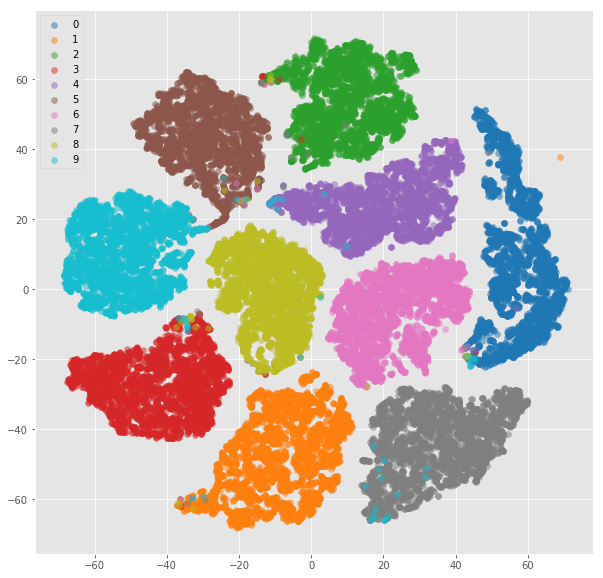

In [15]:
mnist_classes = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

plt.figure(figsize=(10,10))
for i in range(10):
    inds = np.where(y_train==i)[0]
    plt.scatter(X_embedded[inds,0], X_embedded[inds,1], alpha=0.5, color=colors[i])
plt.legend(mnist_classes)